# 00 — Geometric Objects


## Intuition

A smooth 3D surface cannot be stored exactly in a computer — we *discretise* it. We sample a finite set of points on the surface (the **vertices**) and record which triples of points form flat triangular patches (the **faces**). The result is a **triangle mesh**: a piecewise-flat approximation that converges to the smooth surface as the number of triangles grows.

A **point cloud** is even simpler: just a set of 3D points with no connectivity. You lose the notion of "which points are neighbours", but point clouds are what you get directly from a 3D scanner.

The same representation works for any surface: a flat plane, a sphere, a doughnut (torus), a human face, a cat.

## Minimal math

A triangle mesh is a pair $(V, F)$:

$$V \in \mathbb{R}^{n \times 3} \qquad n \text{ vertex positions in 3D}$$

$$F \in \{0,\ldots,n-1\}^{m \times 3} \qquad m \text{ triangles, each stored as a triple of vertex indices}$$

Each triangle $t$ with vertices $v_i, v_j, v_k$ has area $|t| = \frac{1}{2}\|(v_j - v_i) \times (v_k - v_i)\|$.

Each vertex $v_i$ is assigned an **area weight** — one third of the total area of all triangles touching it:

$$a_i = \frac{1}{3} \sum_{t \ni i} |t|, \qquad \sum_{i=1}^n a_i = \text{total surface area}$$

These weights are the diagonal of the **mass matrix** $M = \mathrm{diag}(a_1,\ldots,a_n)$ and will appear in every inner product we define on functions (notebook 01).

In [1]:
import sys
from pathlib import Path

import numpy as np
from scipy.spatial import ConvexHull

import geomfum
from geomfum.dataset import NotebooksDataset
from geomfum.shape import PointCloud, TriangleMesh

In [2]:
notebooks_dir = Path(geomfum.__file__).resolve().parents[1] / "notebooks"
notebooks_dir_str = str(notebooks_dir)
if notebooks_dir_str not in sys.path:
    sys.path.insert(0, notebooks_dir_str)

from plot_utils import setup_pyvista, show_mesh, show_point_cloud  # noqa: E402

setup_pyvista()

## Geometric object 1: the sphere

We sample random points on the unit sphere and take their **convex hull** — the smallest convex shape enclosing all points. For points on a sphere, the convex hull *is* the sphere.

In [3]:
rng = np.random.default_rng(0)
pts = rng.standard_normal((800, 3))
pts /= np.linalg.norm(pts, axis=1, keepdims=True)  # project onto unit sphere

hull = ConvexHull(pts)
sphere_v = hull.points  # (n, 3)
sphere_f = hull.simplices  # (m, 3)  triangular faces

print(f"Sphere — vertices: {sphere_v.shape[0]},  faces: {sphere_f.shape[0]}")

Sphere — vertices: 800,  faces: 1596


In [4]:
# Wrap in geomfum to access vertex areas
sphere = TriangleMesh(vertices=sphere_v, faces=sphere_f)
a_sphere = sphere.vertex_areas

print(
    f"Total surface area ≈ {a_sphere.sum():.4f}  (unit sphere exact = 4π ≈ {4 * np.pi:.4f})"
)

Total surface area ≈ 12.4708  (unit sphere exact = 4π ≈ 12.5664)


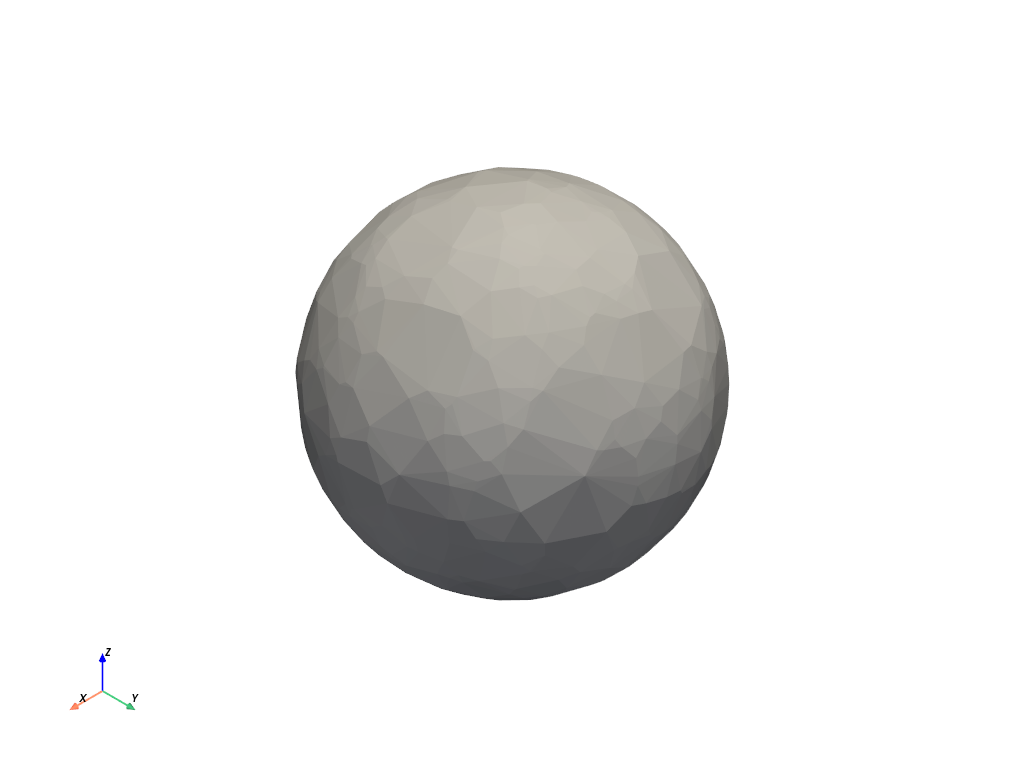

In [5]:
show_mesh(
    sphere_v,
    sphere_f,
    # scalars=a_sphere,
    # scalar_name="vertex area",
    cmap="Blues",
    smooth=False,
)

## Geometric object 2: the torus

A **torus** (doughnut) is parameterised by two radii: $R$ (from the centre to the tube centre) and $r$ (tube radius). It is the simplest shape with a *hole* — a fundamentally different topology from a sphere.

$$x(u,v) = (R + r\cos v)\cos u, \quad y(u,v) = (R + r\cos v)\sin u, \quad z(u,v) = r\sin v$$

with $u, v \in [0, 2\pi)$.

In [6]:
def make_torus(R=1.0, r=0.35, n_major=50, n_minor=25):
    """Parametric torus mesh. R = major radius, r = minor (tube) radius."""
    u = np.linspace(0, 2 * np.pi, n_major, endpoint=False)
    v = np.linspace(0, 2 * np.pi, n_minor, endpoint=False)
    U, V = np.meshgrid(u, v, indexing="ij")

    x = (R + r * np.cos(V)) * np.cos(U)
    y = (R + r * np.cos(V)) * np.sin(U)
    z = r * np.sin(V)
    vertices = np.column_stack([x.ravel(), y.ravel(), z.ravel()])

    faces = []
    for i in range(n_major):
        for j in range(n_minor):
            v0 = i * n_minor + j
            v1 = i * n_minor + (j + 1) % n_minor
            v2 = ((i + 1) % n_major) * n_minor + j
            v3 = ((i + 1) % n_major) * n_minor + (j + 1) % n_minor
            faces += [[v0, v1, v3], [v0, v3, v2]]

    return vertices, np.array(faces)


torus_v, torus_f = make_torus()
print(f"Torus — vertices: {torus_v.shape[0]},  faces: {torus_f.shape[0]}")

Torus — vertices: 1250,  faces: 2500


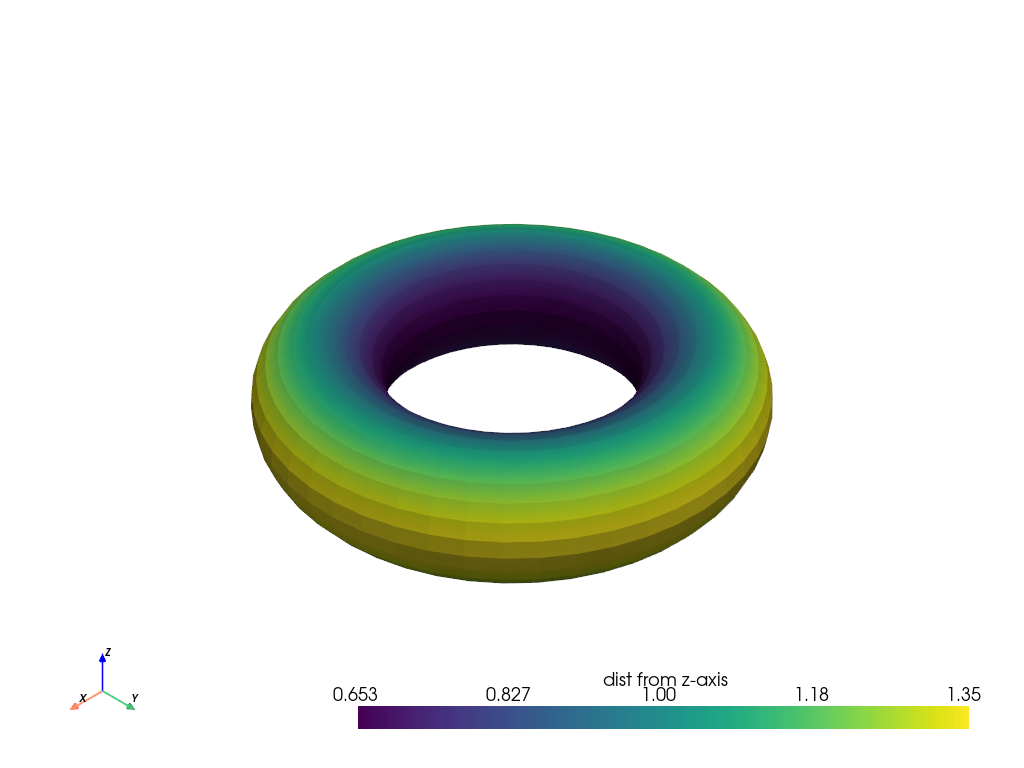

In [7]:
torus = TriangleMesh(vertices=torus_v, faces=torus_f)
a_torus = torus.vertex_areas

# Distance from the z-axis as a natural function on the torus
dist_from_axis = np.sqrt(torus_v[:, 0] ** 2 + torus_v[:, 1] ** 2)

show_mesh(
    torus_v,
    torus_f,
    scalars=dist_from_axis,
    scalar_name="dist from z-axis",
    cmap="viridis",
    smooth=False,
)

## Geometric object 3: a real mesh

`NotebooksDataset` provides a cat shape (~7 000 vertices) used throughout this series. It is a genus-0 surface like the sphere but with a much more complex geometry.

In [8]:
dataset = NotebooksDataset()
mesh = TriangleMesh.from_file(dataset.get_filename("cat-00"))

print(f"Cat — vertices: {mesh.n_vertices},  faces: {mesh.n_faces}")
print(f"Vertex array shape : {mesh.vertices.shape}")
print(f"Face   array shape : {mesh.faces.shape}")

Cat — vertices: 7207,  faces: 14410
Vertex array shape : (7207, 3)
Face   array shape : (14410, 3)


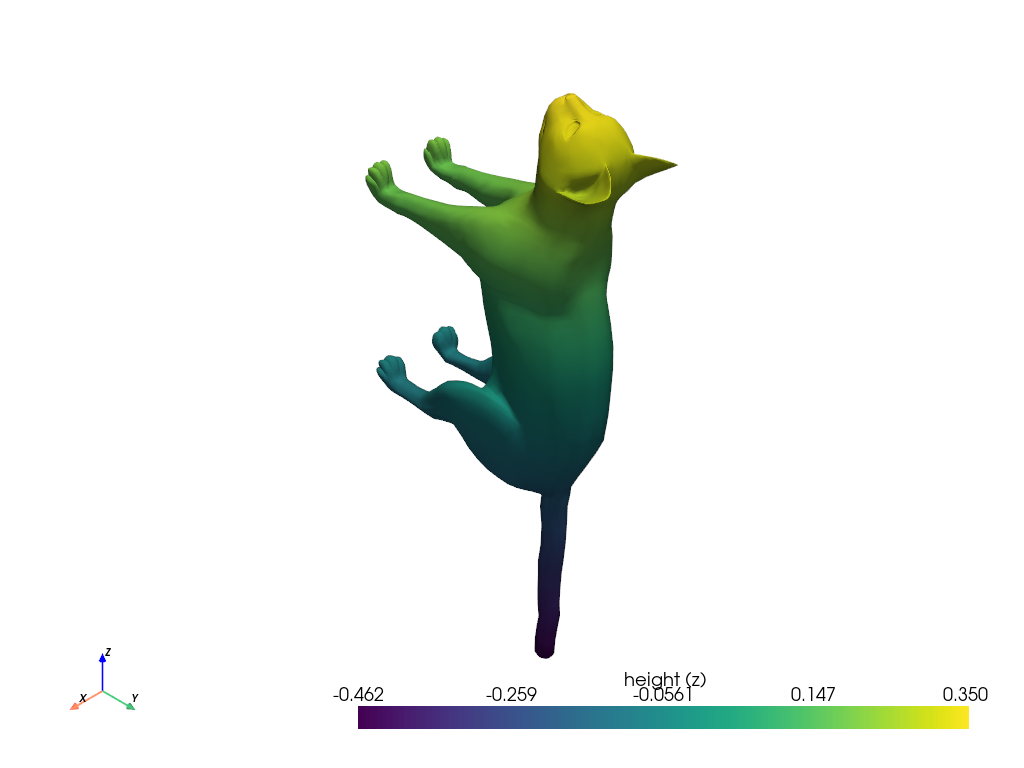

In [9]:
verts = mesh.vertices
faces = mesh.faces
a_cat = mesh.vertex_areas

show_mesh(
    verts,
    faces,
    scalars=verts[:, 2],
    scalar_name="height (z)",
    cmap="viridis",
    smooth=True,
)

## Point clouds

A **point cloud** carries positions but no faces. PyVista can display them as a set of spheres.

Point cloud: 1442 points,  is_mesh = False


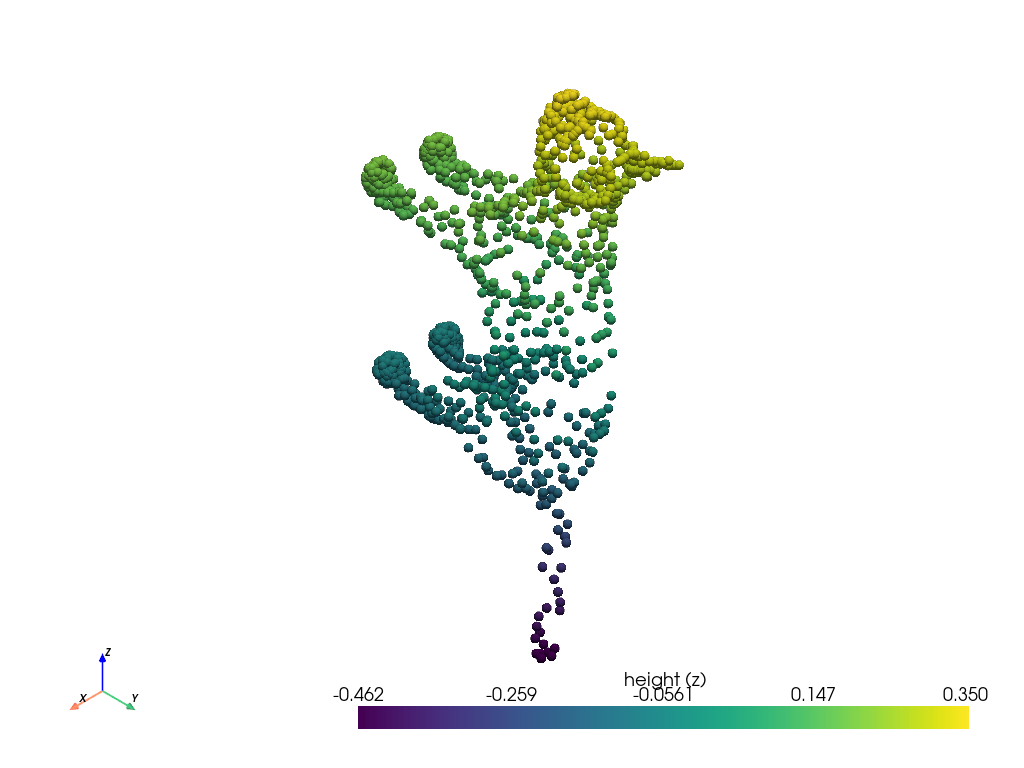

In [10]:
# Subsample the cat to a point cloud (every 10th vertex)
pc_pts = verts[::5]

pc = PointCloud(vertices=pc_pts)
print(f"Point cloud: {pc.n_vertices} points,  is_mesh = {pc.is_mesh}")

show_point_cloud(
    pc_pts,
    scalars=pc_pts[:, 2],
    scalar_name="height (z)",
    cmap="viridis",
    point_size=10,
)

## Where to go next

- [01 — Functions on Shapes](./01_functions_on_shapes.ipynb): what does it mean to attach a value to each vertex?
- [How to load a mesh](../how_to/00_load_mesh_from_file.ipynb)